# Evaluate

In [1]:
import sys
from pathlib import Path

# Kaggle:
# CODE_DIR   = Path("/kaggle/input/datasets/gpla77/project3-code")
# IMAGES_DIR = Path("/kaggle/input/datasets/gpla77/phong-dataset/images")
# PARAMS_DIR = Path("/kaggle/input/datasets/gpla77/phong-dataset/params")
# CKPT_PATH  = Path("/kaggle/input/datasets/gpla77/project3-code/gan_model/checkpoints/G_best.pth")
# OUTPUT_DIR = Path("output")
# RESULTS_DIR = Path("results/test")
# sys.path.insert(0, str(CODE_DIR))

# Local:
IMAGES_DIR = Path("../data/images")
PARAMS_DIR = Path("../data/params")
CKPT_PATH  = Path("checkpoints/G_best.pth")
OUTPUT_DIR = Path("outputs")
RESULTS_DIR = Path("results/test")
sys.path.insert(0, str(Path(".")))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from config import DEVICE

print(f"Device: {DEVICE}")

Device: cpu


In [3]:
from dataset import get_datasets

_, test_ds = get_datasets(IMAGES_DIR, PARAMS_DIR)
print(f"Test samples: {len(test_ds)}")

Train: 2400 | Test: 600
Test samples: 600


## Save generated images for all test samples

In [4]:
import torch
from models import build_models


G, _ = build_models(
    noise_dim  = 8,   
    cond_dim   = 10,
    features_g = 64,
    features_d = 64,
    device     = DEVICE,
)
G.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
G.eval()
print(f"Loaded: {CKPT_PATH}")

Generator      params: 7,107,459
Discriminator  params: 36,841,985
Loaded: checkpoints\G_best.pth


In [5]:
from evaluate import save_test_images


save_test_images(
    G, test_ds,
    save_dir=RESULTS_DIR,
    device=DEVICE,
)

Saving images: 100%|████████████████████████████| 19/19 [00:26<00:00,  1.38s/it]

Saved 600 pairs to results\test


## Compute metrics: FLIP / LPIPS / SSIM / Hausdorff

In [ ]:
import flip_evaluator.flip_python_api as flip_lib
import numpy as np

r_f = np.zeros((128, 128, 3), dtype=np.float32)
f_f = np.ones((128, 128, 3), dtype=np.float32)
result = flip_lib.evaluate(r_f, f_f, "LDR")
print(type(result), len(result))
for i, x in enumerate(result):
    print(i, type(x), np.array(x).shape if hasattr(x, '__len__') else x)

<class 'tuple'> 3
0 <class 'numpy.ndarray'> (128, 128, 3)
1 <class 'float'> 0.9675360918045044
2 <class 'dict'> ()


In [ ]:
from evaluate import run_evaluate


results = run_evaluate(
    G, test_ds,
    output_dir=OUTPUT_DIR,
    device=DEVICE,
)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


d:\STUDIA SZI\Semestr 2\Sztuczna inteligencja w grafice komputerowej\Projekt\repo\AIComputerGraphics\project3-rendering\.pro3-sigk\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\STUDIA SZI\Semestr 2\Sztuczna inteligencja w grafice komputerowej\Projekt\repo\AIComputerGraphics\project3-rendering\.pro3-sigk\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: d:\STUDIA SZI\Semestr 2\Sztuczna inteligencja w grafice komputerowej\Projekt\repo\AIComputerGraphics\project3-rendering\.pro3-sigk\Lib\site-packages\lpips\weights\v0.1\alex.pth
FLIP library available


Evaluating: 100%|███████████████████████████████| 19/19 [01:41<00:00,  5.35s/it]


Method                     FLIP    LPIPS     SSIM  Hausdorff
------------------------------------------------------------
neural_renderer          0.0125   0.1303   0.9650      19.63
Metrics saved to: outputs\metrics.txt


## Visual comparison grid

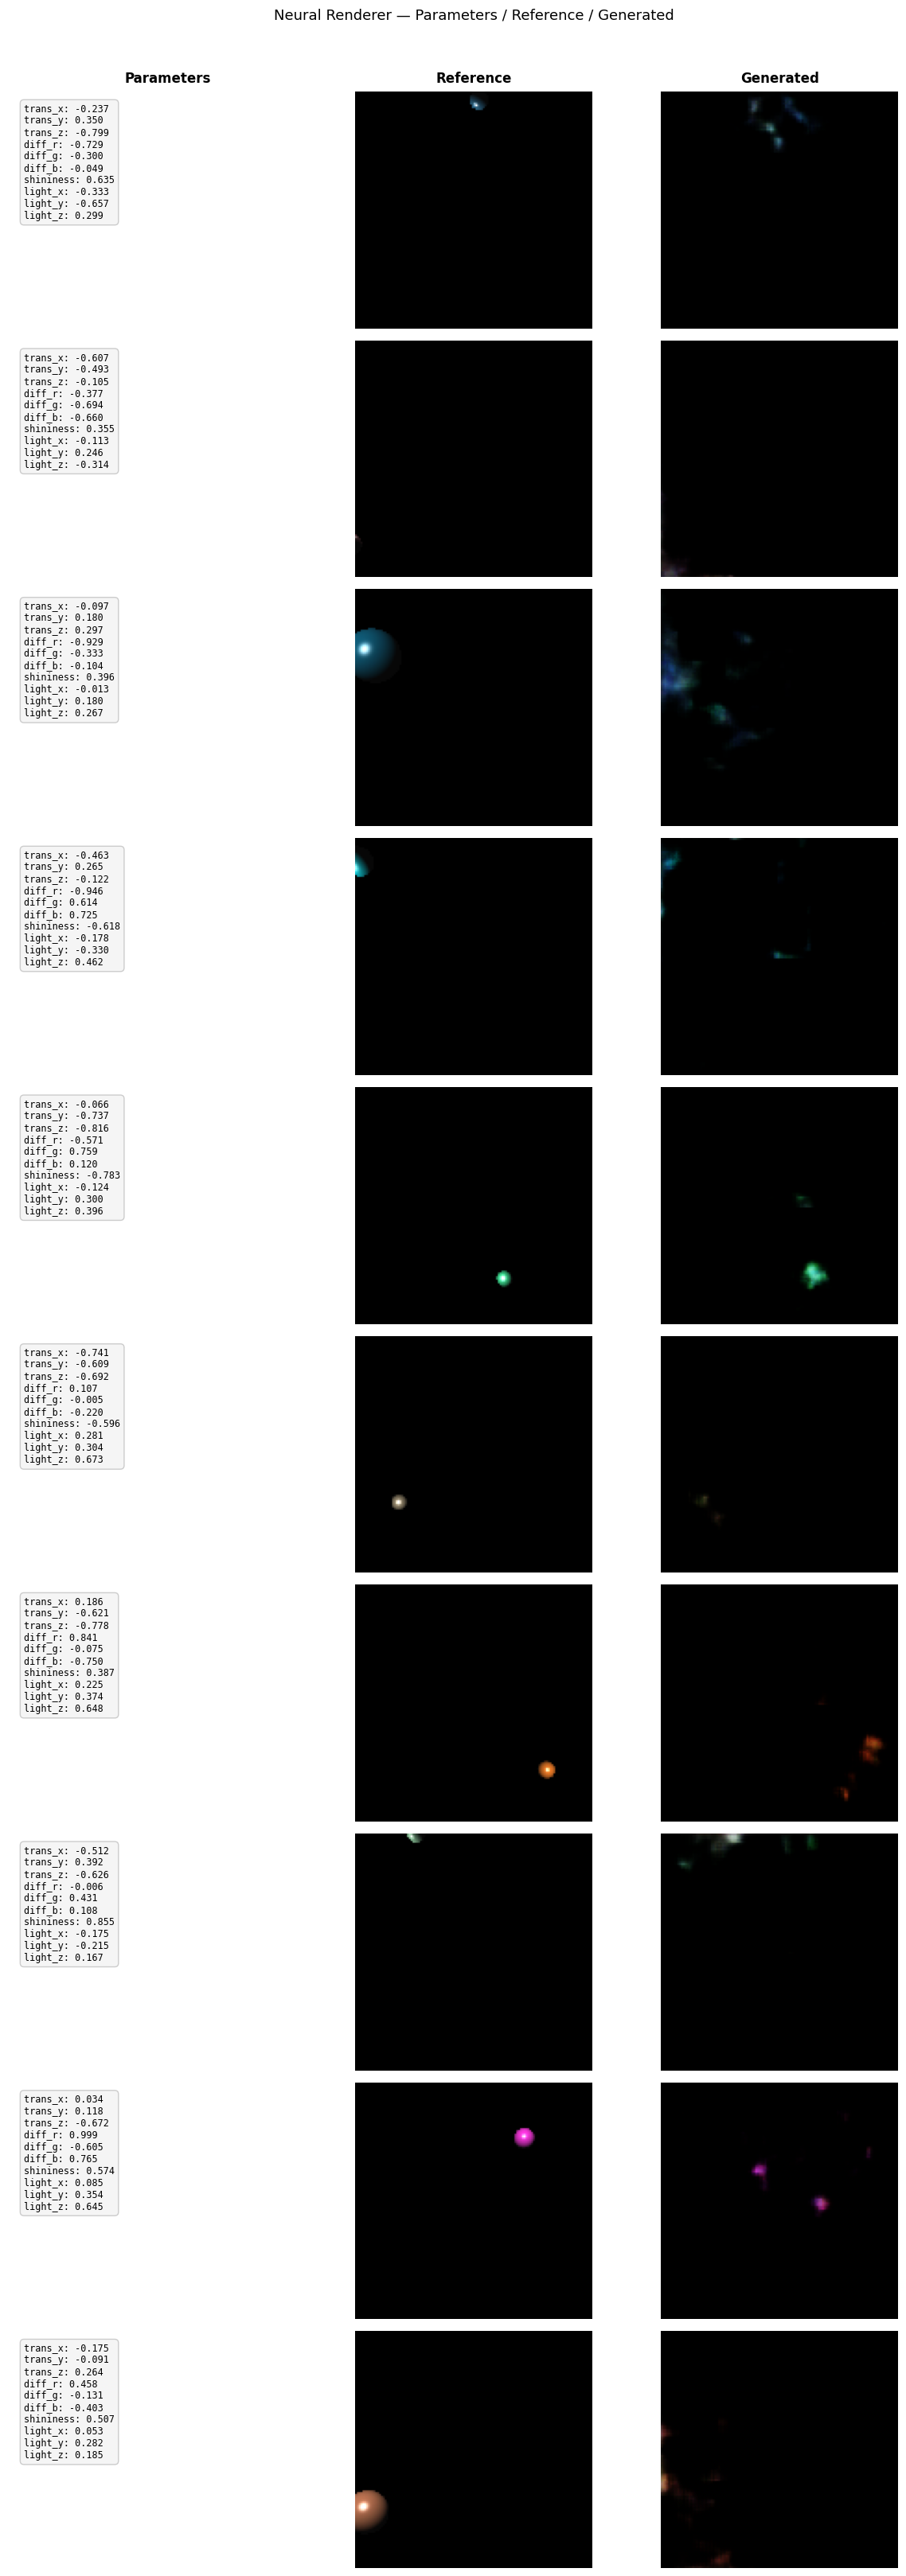

Saved: outputs\results_comparison.png


In [7]:
from evaluate import visualize_results


visualize_results(
    G, test_ds,
    output_dir=OUTPUT_DIR,
    device=DEVICE,
    N=10,
    param_names=[
        "trans_x", "trans_y", "trans_z",
        "diff_r",  "diff_g",  "diff_b",
        "shininess",
        "light_x", "light_y", "light_z",
    ]
)

## Results summary

In [ ]:
import pandas as pd

flip_val = results['FLIP'] if results['FLIP'] is not None else 'N/A'
df = pd.DataFrame([{
    'Method': 'neural_renderer',
    'FLIP': flip_val,
    'LPIPS': round(results['LPIPS'], 4),
    'SSIM': round(results['SSIM'], 4),
    'Hausdorff': round(results['Hausdorff'], 2),
}])
display(df)

,Method,FLIP,LPIPS,SSIM,Hausdorff
0,neural_renderer,0.012508,0.1303,0.965,19.63
